In [604]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import csv
import time
import pandas as pd
import varray as va
import ldax_processing as ldax
from datetime import datetime
from scipy.optimize import curve_fit, minimize

In [583]:
# load latest RQ file without amplification
data_lib = '/Users/bfeike/Documents/TPC_RQs'
raw_lib = '/Users/bfeike/Documents/TPC_data'
d = va.load(f'{data_lib}/2026-01-23-1155_RQ.vrz')
# load cobalt and barium RQ files with amplification
d_co = va.load(f'{data_lib}/2026-02-11-1503_RQ.vrz')
raw_co = f'{raw_lib}/2026-02-11-1503.bin.gz'
d_ba = va.load(f'{data_lib}/2026-02-11-0841_000000_RQ.vrz')
raw_ba = f'{raw_lib}/2026-02-09-1320.bin.gz'

In [584]:
ch_arr = np.arange(32)
all_ch_area = []
all_ch_height = []
spe_area = []
spe_height = []
spe_mean_area = []
spe_mean_height = []
ch_area = []
ch_height = []
ch_eventid_arr = []
ch_pulseid_arr = []

# Extract all channel pulse areas and heights with cut applied:

for ch in ch_arr:
    ch_area = d['p_area_ch'][:,ch,:].flatten()
    ch_height = d['p_height_ch'][:,ch,:].flatten()
    if ch == 0 | ch == 5 | ch == 14:
        cut_spe = (ch_height < 8) & (ch_height > 2) & (ch_area > 0)
    elif ch == 6 | ch == 8 | ch == 9 | ch == 10 | ch == 11 | ch == 13 | ch == 15 | ch == 17 | ch == 18 | ch == 19 | ch == 21 | ch == 25 :
        cut_spe = (ch_height < 7.5) & (ch_height > 2) & (ch_area > 0)
    else:
        cut_spe = (ch_height < 7) & (ch_height > 2) & (ch_area > 0)
        
    ch_spe_area = ch_area[cut_spe]
    ch_spe_height = ch_height[cut_spe]
    ch_spe_mean_area = np.mean(ch_spe_area)
    ch_spe_mean_height = np.mean(ch_spe_height)

    all_ch_area.append(ch_area)
    all_ch_height.append(ch_height)
    spe_area.append(ch_spe_area)
    spe_height.append(ch_spe_height)
    spe_mean_area.append(ch_spe_mean_area)
    spe_mean_height.append(ch_spe_mean_height)

In [612]:
ch_arr = np.arange(32)
all_ch_area_co = []
all_ch_height_co = []
all_ch_eventids_co = []
all_ch_pulseids_co = []
spe_area_co = []
spe_height_co = []
spe_mean_area_co = []
spe_mean_height_co = []
ch_area = []
ch_height = []
ch_eventid_arr = []
ch_pulseid_arr = []

#cut_oce = d_co['p_class'] == 3
# Calculate all channel pulse areas and heights with cut applied:

for ch in ch_arr:
    ch_area = d_co['p_area_ch'][cut_oce][:,ch,:].flatten()
    ch_height = d_co['p_height_ch'][cut_oce][:,ch,:].flatten()
    ch_eventid_arr = d_co['p_area_ch'][cut_oce].get_row_index()[:,ch,:].flatten()
    ch_pulseid_arr = d_co['p_area_ch'][cut_oce].get_col_index()[:,ch,:].flatten()
    
    cut_spe = (ch_height < 15) & (ch_height > 5) & (ch_area > 0) & (ch_area < 200)
        
    ch_spe_area = ch_area[cut_spe]
    ch_spe_height = ch_height[cut_spe]
    ch_spe_mean_area = np.mean(ch_spe_area)
    ch_spe_mean_height = np.mean(ch_spe_height)

    all_ch_area_co.append(ch_area)
    all_ch_height_co.append(ch_height)
    all_ch_eventids_co.append(ch_eventid_arr)
    all_ch_pulseids_co.append(ch_pulseid_arr)
    spe_area_co.append(ch_spe_area)
    spe_height_co.append(ch_spe_height)
    spe_mean_area_co.append(ch_spe_mean_area)
    spe_mean_height_co.append(ch_spe_mean_height)

In [586]:
ch_arr = np.arange(32)
all_ch_area_ba = []
all_ch_height_ba = []
all_ch_eventids_ba = []
all_ch_pulseids_ba = []
spe_area_ba = []
spe_height_ba = []
spe_mean_area_ba = []
spe_mean_height_ba = []
ch_area = []
ch_eventid_arr = []
ch_pulseid_arr = []
ch_height = []

# Calculate all channel pulse areas and heights with cut applied:

for ch in ch_arr:
    ch_area = d_ba['p_area_ch'][:,ch,:].flatten()
    ch_height = d_ba['p_height_ch'][:,ch,:].flatten()
    ch_eventid_arr = d_ba['p_area_ch'].get_row_index()[:,ch,:].flatten()
    ch_pulseid_arr = d_ba['p_area_ch'].get_col_index()[:,ch,:].flatten()
    
    cut_spe = (ch_height < 15) & (ch_height > 5) & (ch_area > 0)
    
    ch_spe_area = ch_area[cut_spe]
    ch_spe_height = ch_height[cut_spe]
    ch_spe_mean_area = np.mean(ch_spe_area)
    ch_spe_mean_height = np.mean(ch_spe_height)

    all_ch_area_ba.append(ch_area)
    all_ch_height_ba.append(ch_height)
    all_ch_eventids_ba.append(ch_eventid_arr)
    all_ch_pulseids_ba.append(ch_pulseid_arr)
    spe_area_ba.append(ch_spe_area)
    spe_height_ba.append(ch_spe_height)
    spe_mean_area_ba.append(ch_spe_mean_area)
    spe_mean_height_ba.append(ch_spe_mean_height)

In [587]:
# Error of the mean estimation (standard error)
def mu_err(spe_area, spe_height, ch_arr):
    sigma_area_arr = []
    sigma_height_arr = []
    stmean_area_arr = []
    stmean_height_arr = []
    
    for ch in ch_arr:
        n = len(spe_area[ch])
        sigma_area_arr.append(np.std(spe_area[ch]))
        sigma_height_arr.append(np.std(spe_height[ch]))
        stmean_area_arr.append(np.std(spe_area[ch])/np.sqrt(n))
        stmean_height_arr.append(np.std(spe_height[ch])/np.sqrt(n))
        
    return sigma_area_arr, sigma_height_arr, stmean_area_arr, stmean_height_arr

In [588]:
#sigma_area_0, sigma_height_0, stmean_area_0, stmean_height_0 = mu_err(spe_area, spe_height, ch_arr)
sigma_area_co, sigma_height_co, stmean_area_co, stmean_height_co = mu_err(spe_area_co, spe_height_co, ch_arr)
sigma_area_ba, sigma_height_ba, stmean_area_ba, stmean_height_ba = mu_err(spe_area_ba, spe_height_ba, ch_arr)

In [9]:
def Gaussian(x, peak, sigma, mu):
    return(peak*(1/(sigma*np.sqrt(2*np.pi)))*np.exp((-(x-mu)**2/(2*sigma**2))))

def gaussfit(el, sigma_area, ch_arr):
    if el == 0:
        spe_area_el = spe_area_co
    elif el == 1:
        spe_area_el = spe_area_ba
    pres = np.zeros((32, 3))
    prescov = np.zeros((32,3,3))
    err_mean_area = np.zeros((32))
    for ch in ch_arr:
        fig, axs = plt.subplots(nrows=16, ncols=2);
        ax = axs.flatten();
        counts, bins, patches = ax[ch].hist(spe_area_el[ch], edgecolor='black', bins=100, range=[0,500]);
        plt.close()
        bins = (bins[:-1]+bins[1:])/2
        popt, pcov = curve_fit(Gaussian,xdata=bins,ydata=counts,p0=(100,20,100),sigma=sigma_area[ch],bounds=([0,0,0],[100000,100,1000]),maxfev=10000)
        pres[ch] = popt
        prescov[ch] = pcov
        err_mean_area[ch] = pcov[2,2]
        
    return pres, prescov, err_mean_area

In [10]:
pres_co, prescov_co, err_mean_area_co = gaussfit(0, sigma_area_co, ch_arr)
pres_ba, prescov_ba, err_mean_area_ba = gaussfit(1, sigma_area_ba, ch_arr)

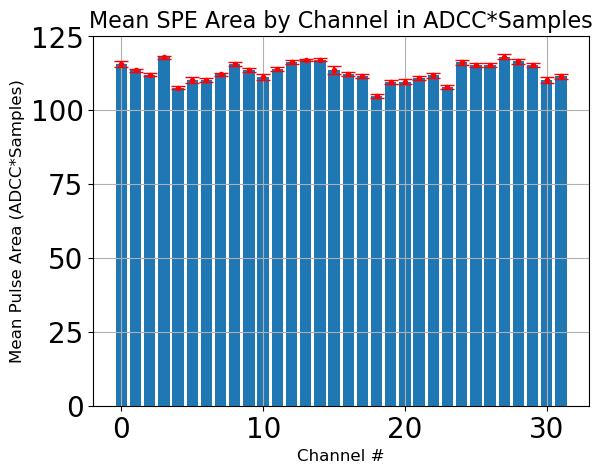

Channel 0: 115.53 +/- 1.02
Channel 1: 113.51 +/- 0.778
Channel 2: 112.09 +/- 0.74
Channel 3: 117.86 +/- 0.698
Channel 4: 107.63 +/- 0.744
Channel 5: 110.28 +/- 0.967
Channel 6: 110.17 +/- 0.796
Channel 7: 112.21 +/- 0.727
Channel 8: 115.51 +/- 0.811
Channel 9: 113.71 +/- 0.8
Channel 10: 111.31 +/- 0.96
Channel 11: 114.02 +/- 0.822
Channel 12: 116.23 +/- 0.849
Channel 13: 116.96 +/- 0.677
Channel 14: 117.05 +/- 0.723
Channel 15: 113.7 +/- 1.18
Channel 16: 112.29 +/- 0.877
Channel 17: 111.56 +/- 0.823
Channel 18: 104.79 +/- 0.788
Channel 19: 109.69 +/- 0.821
Channel 20: 109.71 +/- 0.921
Channel 21: 110.98 +/- 0.857
Channel 22: 111.8 +/- 0.857
Channel 23: 107.94 +/- 0.787
Channel 24: 116.16 +/- 0.955
Channel 25: 115.23 +/- 0.83
Channel 26: 115.31 +/- 0.878
Channel 27: 118.15 +/- 0.988
Channel 28: 116.5 +/- 0.946
Channel 29: 115.3 +/- 0.798
Channel 30: 110.19 +/- 0.973
Channel 31: 111.49 +/- 0.898


In [ ]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.bar(ch_arr, pres_co[:,2])
plt.errorbar(ch_arr, pres_co[:,2], yerr=err_mean_area_co, color='r', fmt='.', capsize=5)
plt.grid()
plt.xlabel('Channel #', fontsize=12)
plt.ylabel('Mean Pulse Area (ADCC*Samples)', fontsize=12)
plt.title('Mean SPE Area by Channel in ADCC*Samples', fontsize=16)
plt.show()
for ch in ch_arr:
    print(f'Channel {ch}: {pres_co[ch,2]:.5g} +/- {np.sqrt(err_mean_area_co[ch]):.3g}')

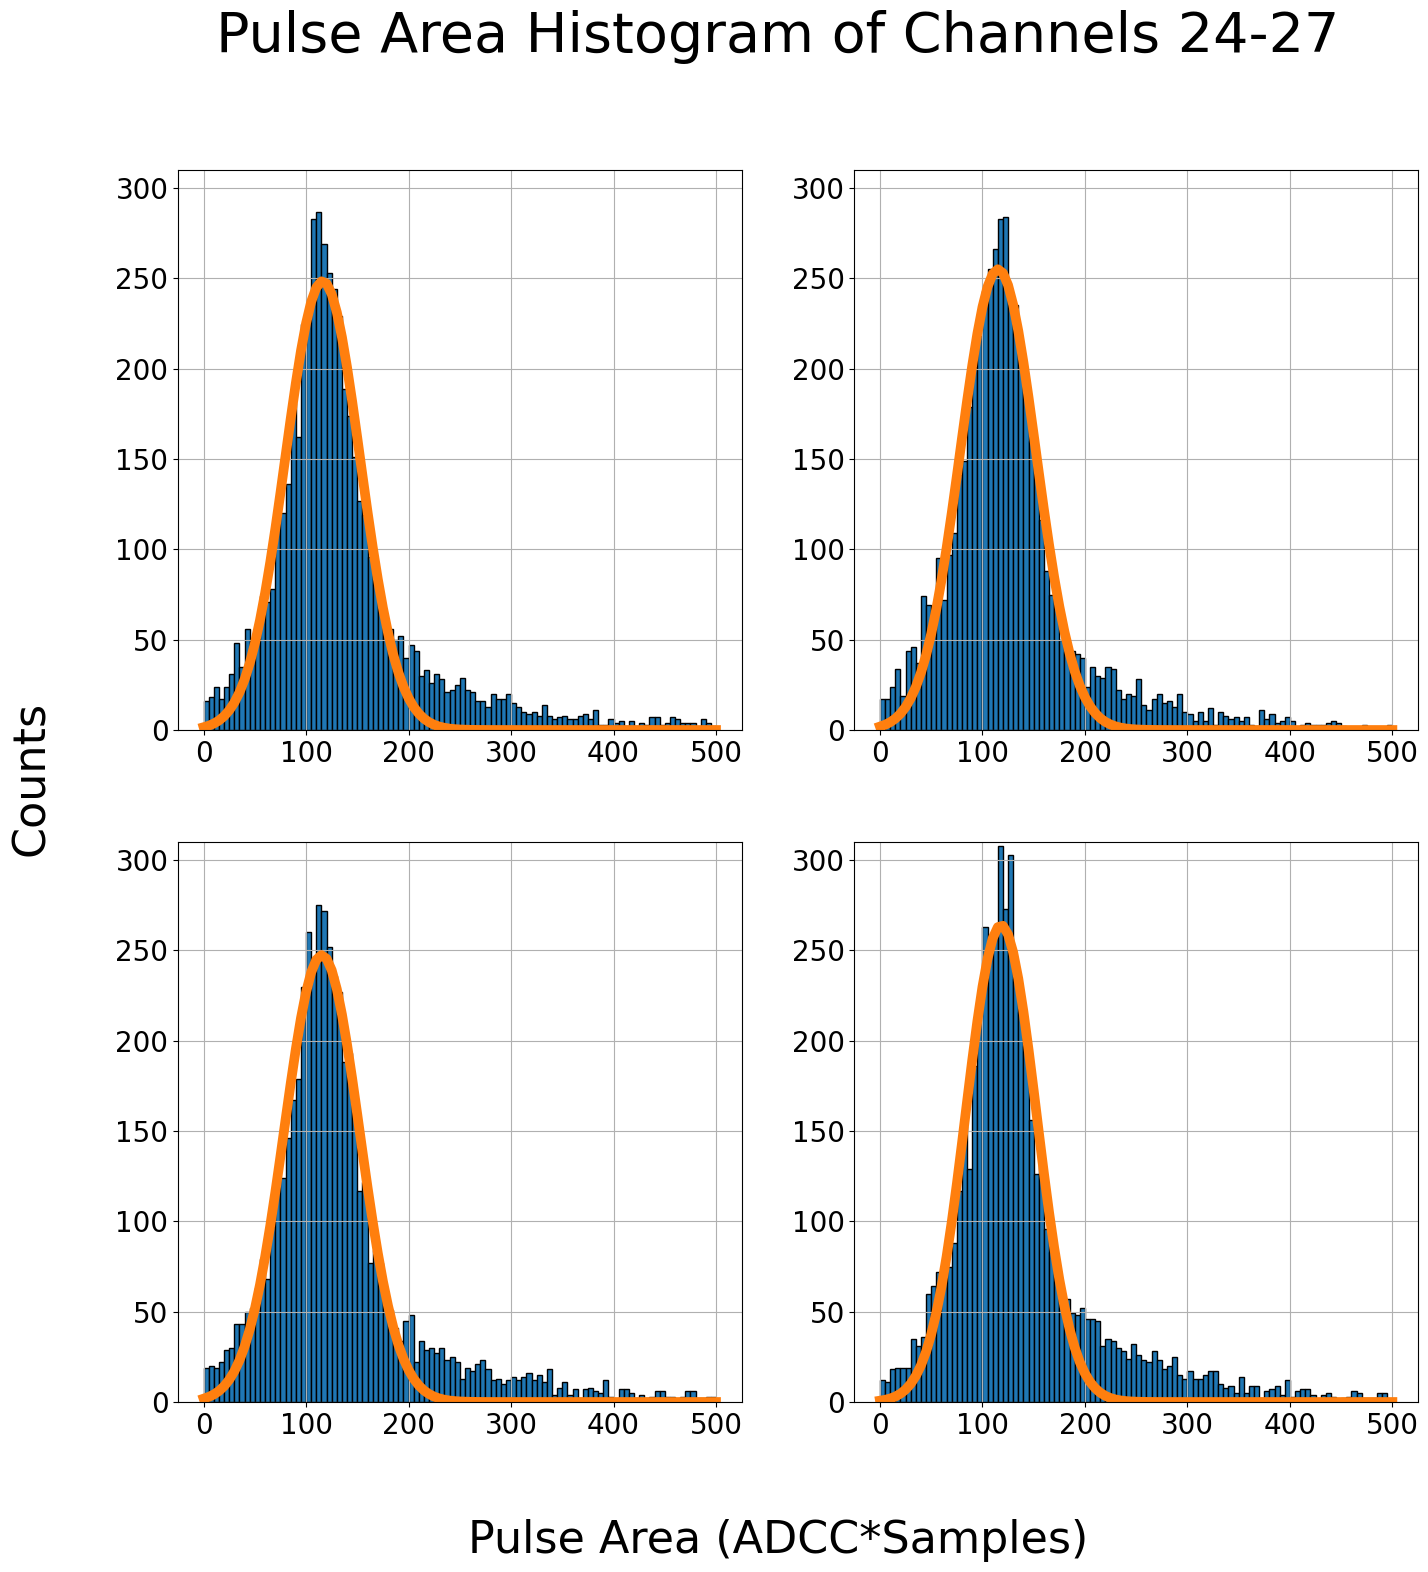

In [ ]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
for i in np.arange(len(axs)+2):
    j = i+24
    ax = axs.flatten()
    counts, bins, patches = ax[i].hist(spe_area_co[j], edgecolor='black', bins=100, range=[0,500])
    ax[i].plot(bins, Gaussian(bins, pres_co[j,0], pres_co[j,1], pres_co[j,2]), lw=7)
    ax[i].set_ylim(0, 310)
    ax[i].grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=32)
fig.supylabel('Counts', fontsize=32)
fig.suptitle('Pulse Area Histogram of Channels 24-27', fontsize=40)
plt.show()

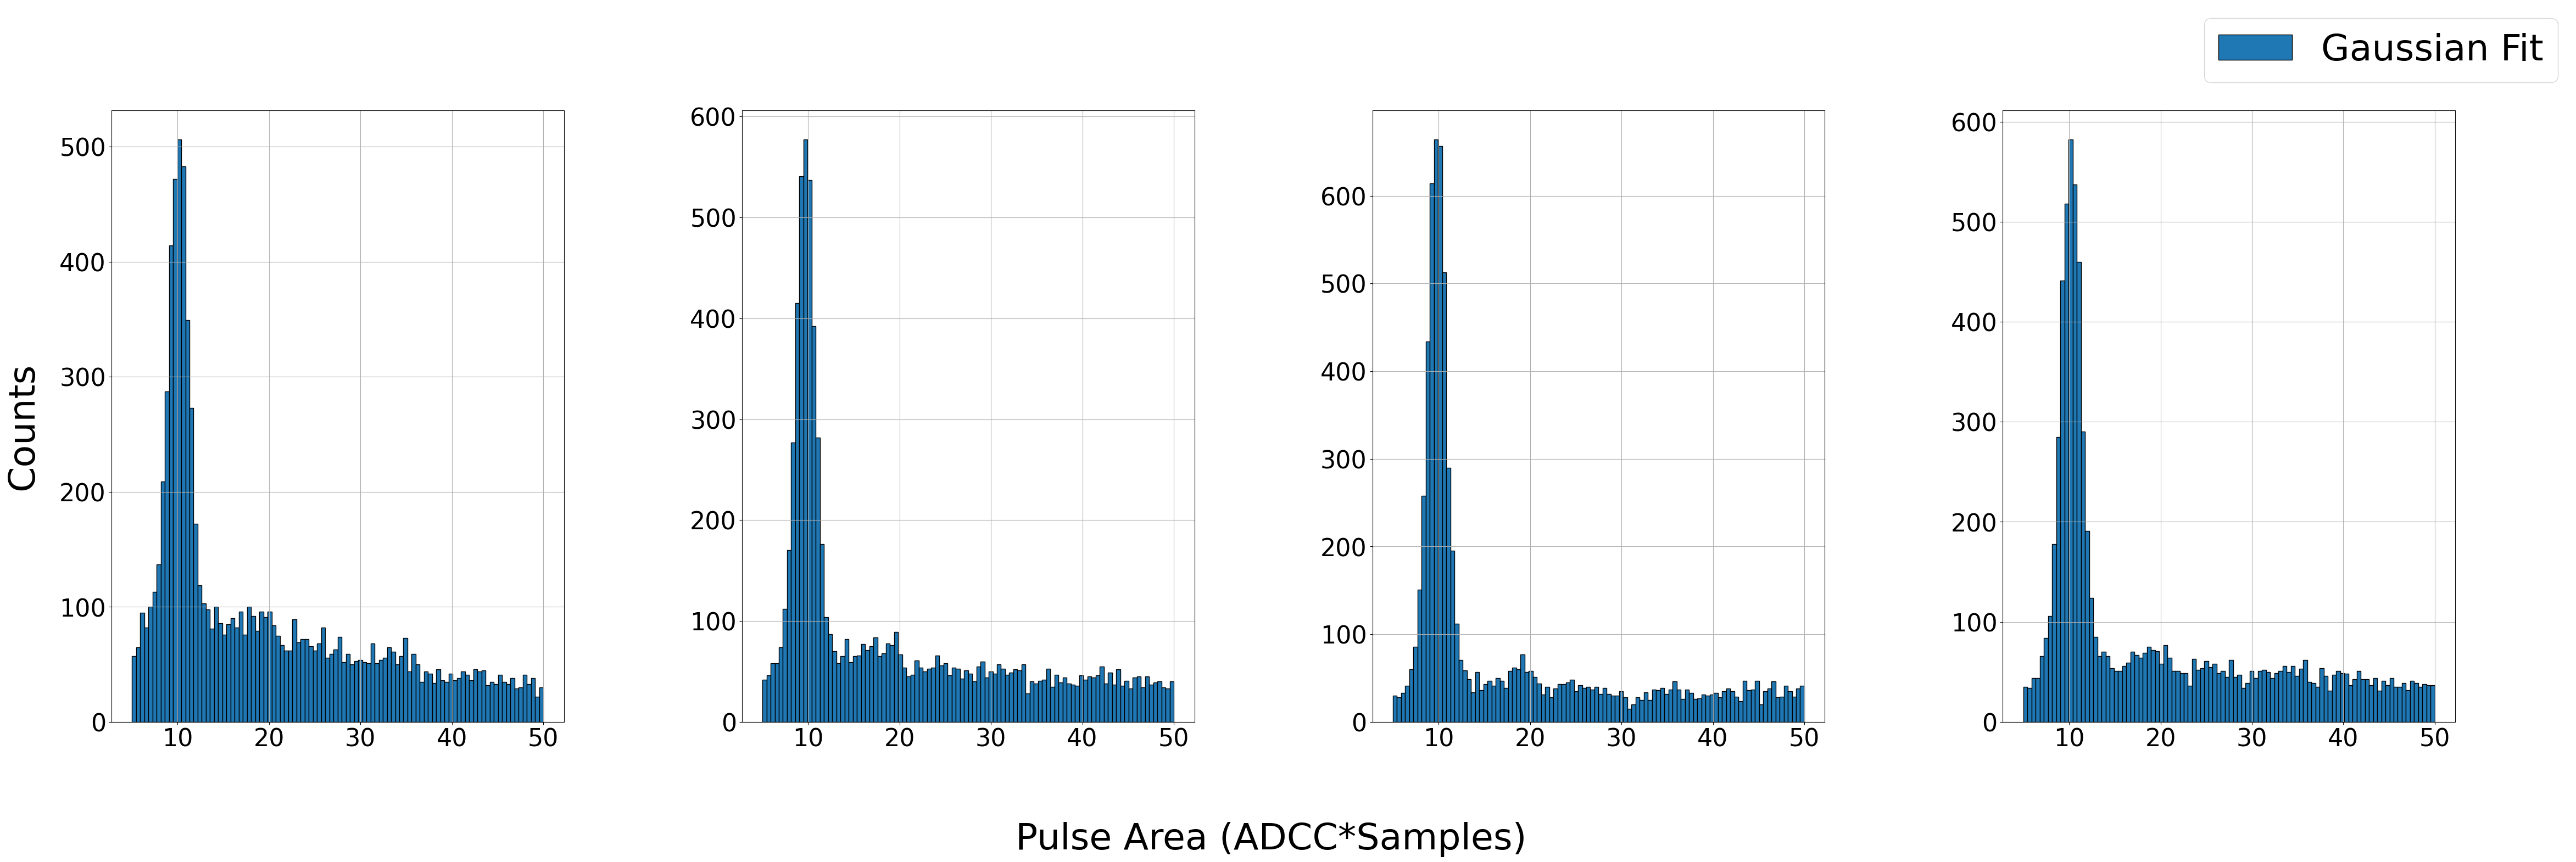

In [187]:
plt.rc('xtick', labelsize=32)
plt.rc('ytick', labelsize=32)
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(48,16))
plt.tight_layout(pad=15, h_pad=None, w_pad=None, rect=None)
for i in np.arange(4):
    j = i+0
    ax = axs.flatten()
    counts, bins, patches = ax[i].hist(all_ch_height_co[j], edgecolor='black', bins=100, range=[5,50])
    bins = (bins[:-1]+bins[1:])/2
    #ax[i].plot(bins, Gaussian(bins, pres_co[j,0], pres_co[j,1], pres_co[j,2]), lw=5)
    #ax[i].set_ylim(0,300)
    ax[i].grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=48)
fig.supylabel('Counts', fontsize=48)
fig.legend(labels=['Gaussian Fit'], fontsize=48)
plt.show()

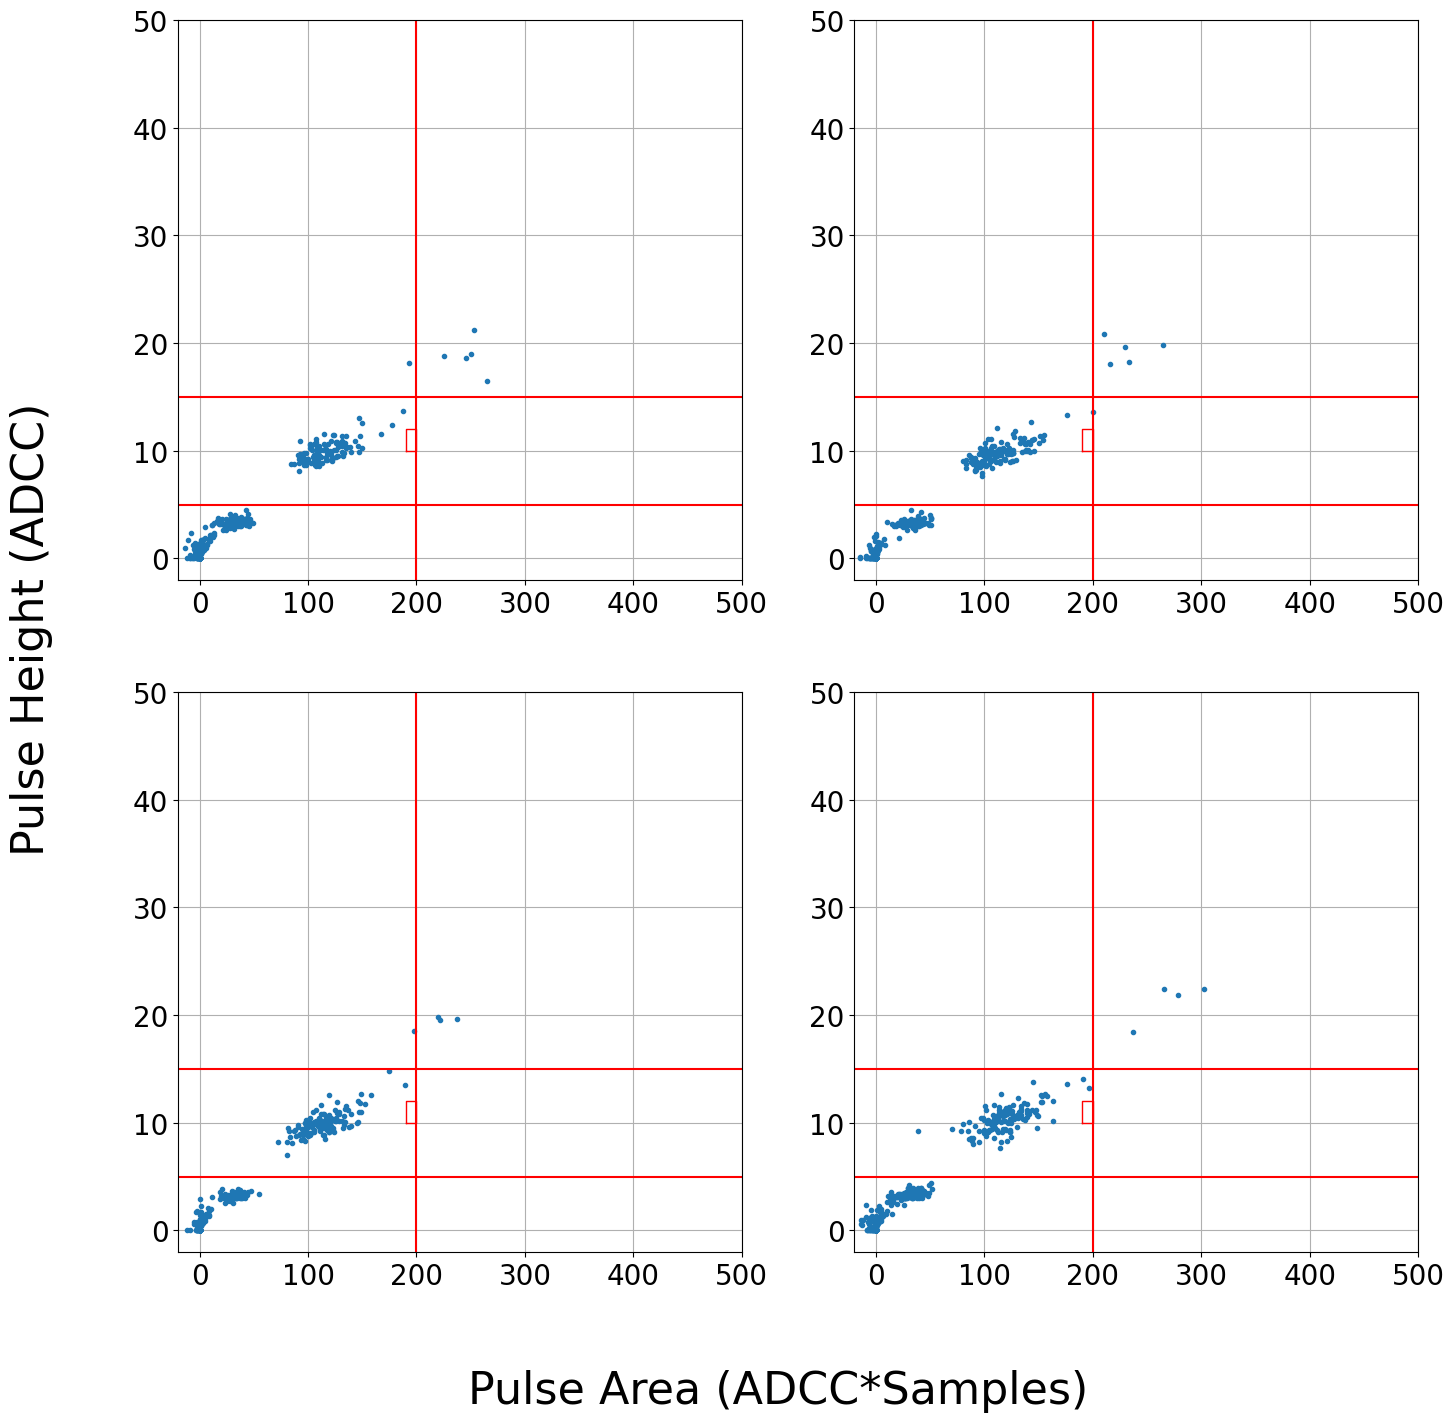

In [611]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
x0 = 0
x1 = 200
y0 = 15
y1 = 5
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
for i in np.arange(len(axs)+2):
    ax = axs.flatten()
    ax[i].plot(all_ch_area_co[i+0], all_ch_height_co[i+0],'.')
    ax[i].plot(np.r_[190,200,200,190,190],np.r_[10,10,12,12,10],'r-',lw=1)
    ax[i].axline((x0, y0), (x1, y0), color='r')
    ax[i].axline((x0, y1), (x1, y1), color='r')
    ax[i].axvline(x=200, color='r')
    ax[i].set_xlim(-20, 500)
    ax[i].set_ylim(-2, 50)
    ax[i].grid()
fig.supxlabel('Pulse Area (ADCC*Samples)', fontsize=32)
fig.supylabel('Pulse Height (ADCC)', fontsize=32)
plt.show()

cut_ch_eventids = []
cut_ch_pulseids = []
for i in np.arange(32):
    cut_box = (all_ch_area_co[i]>190)&(all_ch_area_co[i]<200)&(all_ch_height_co[i]>10)&(all_ch_height_co[i]<12)
    cut_ch_eventids.append(all_ch_eventids_co[i][cut_box])
    cut_ch_pulseids.append(all_ch_pulseids_co[i][cut_box])

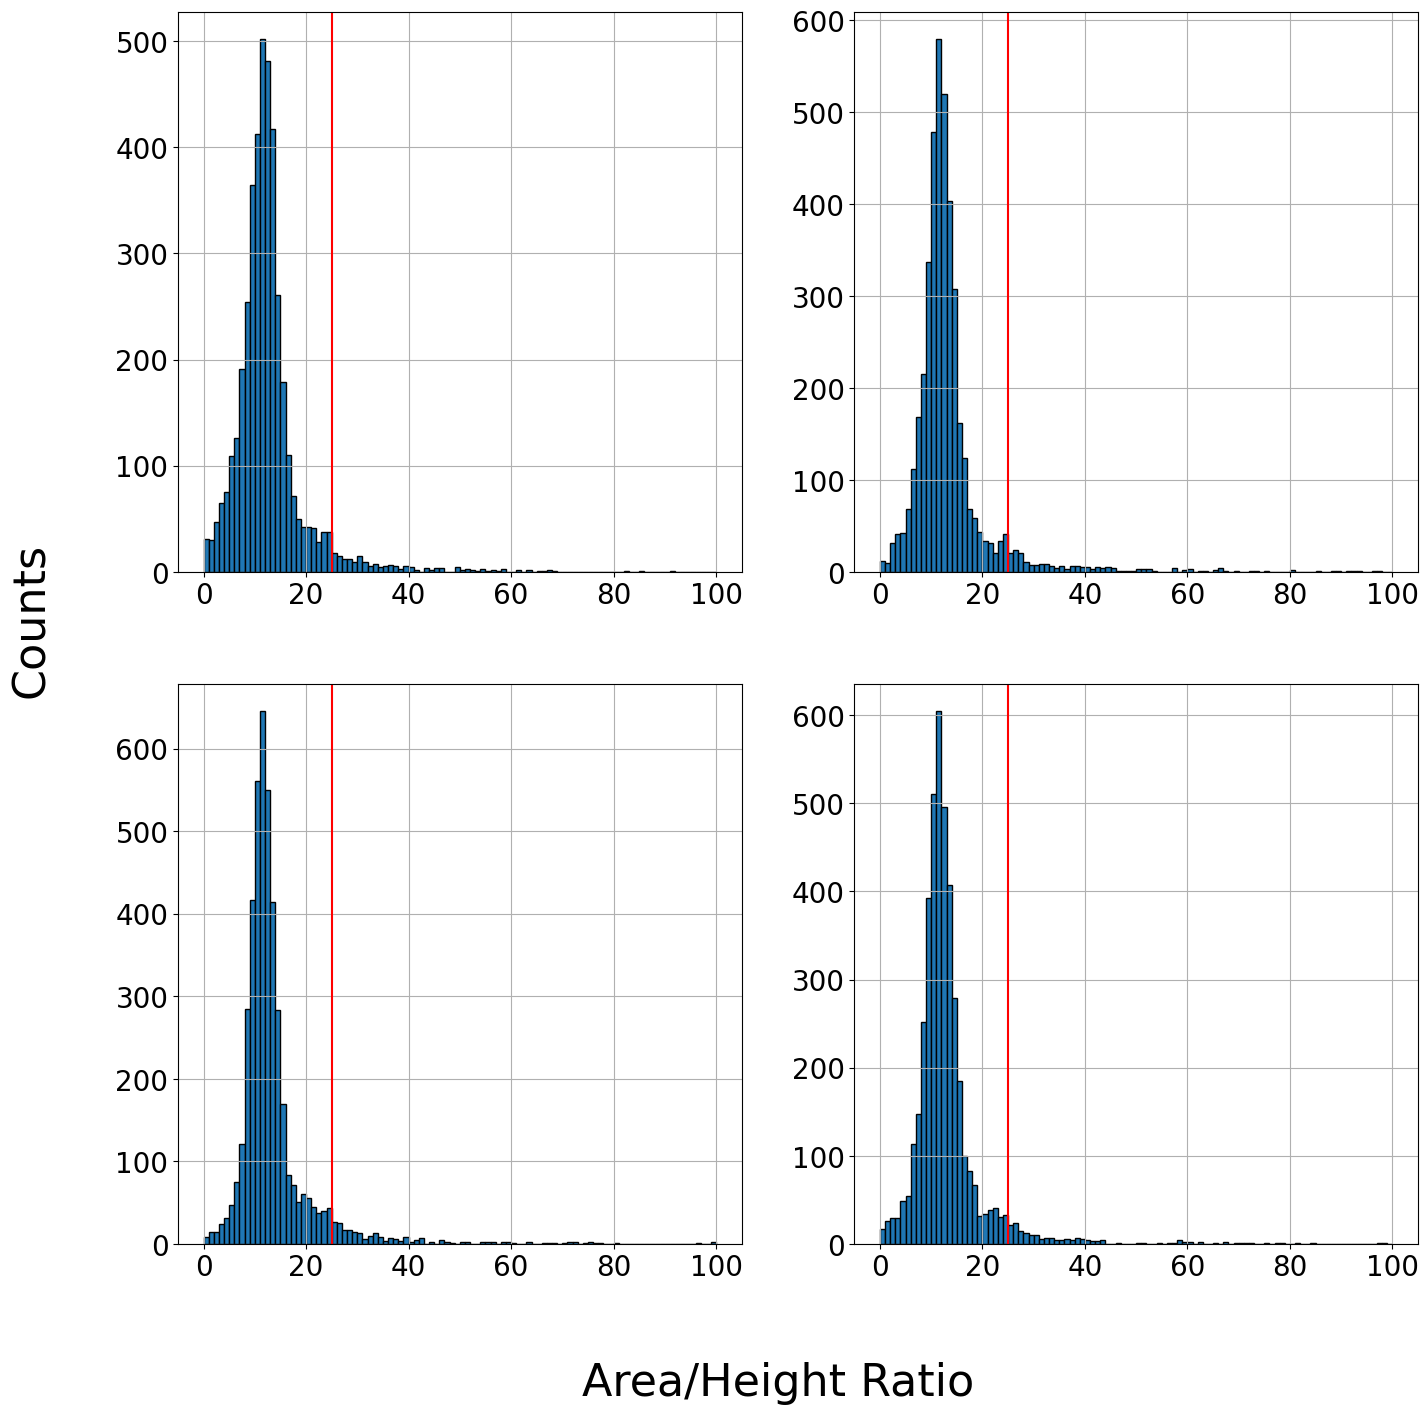

In [ ]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
for i in np.arange(len(axs)+2):
    j = i+0
    ax = axs.flatten()
    counts, bins, patches = ax[i].hist(spe_area_co[j]/spe_height_co[j], edgecolor='black', bins=100, range=[0,100])
    ax[i].axvline(x=25, color='r')
    ax[i].grid()
fig.supxlabel('Area/Height Ratio', fontsize=32)
fig.supylabel('Counts', fontsize=32)
plt.show()

In [285]:
#waveforms_ba, wav_info_ba, header_ba = ldax.Read_DDC40_fName(raw_ba)
#print(waveforms_ba.shape)

waveforms_co, wav_info_co, header_co = ldax.Read_DDC40_fName(raw_co)
print(waveforms_co.shape)

(10000, 32, 2048)


In [580]:
cut_adcc = np.any(waveforms_co, axis=(2), where=waveforms_co<-7200)
wf_ch_eventids = np.argwhere(cut_adcc)

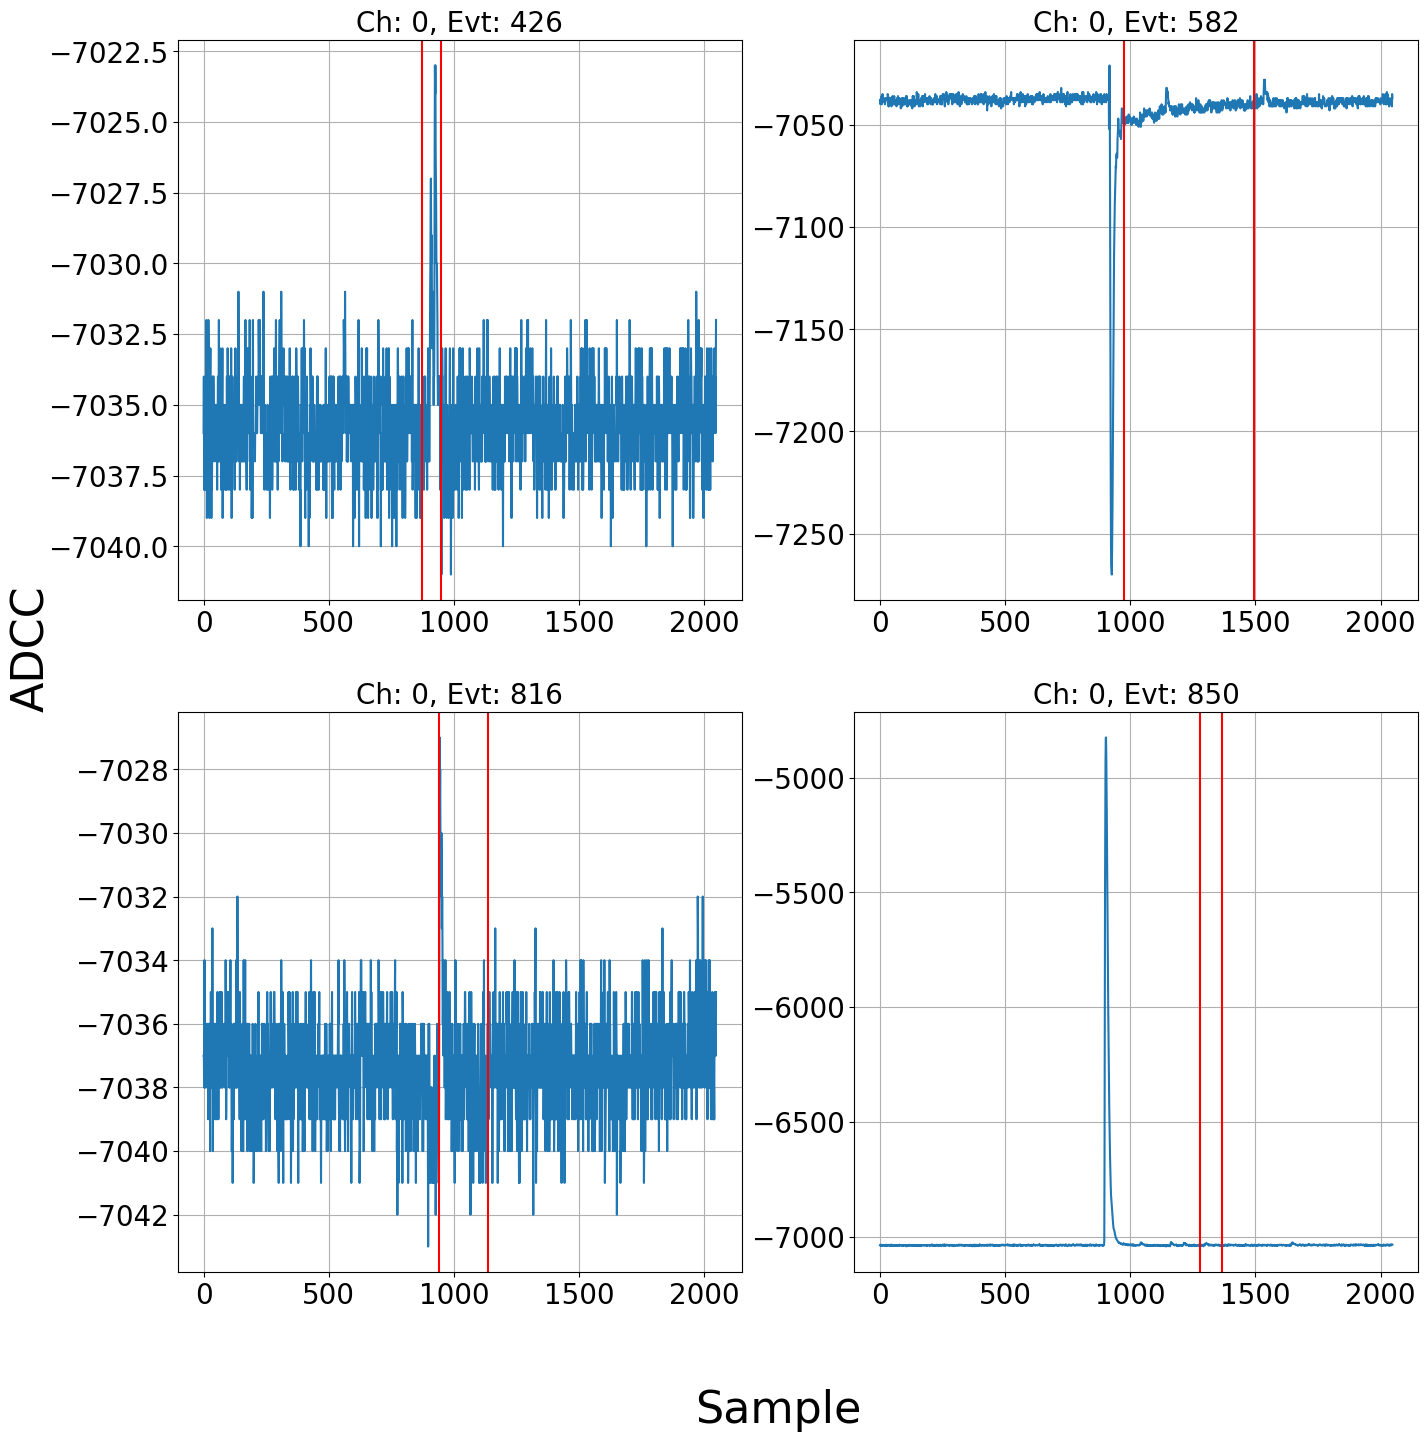

In [470]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
for i in np.arange(len(axs)+2):
    ch = 0
    j = i+0
    ax = axs.flatten()
    # Format: [cut_ch_eventids[ch][event]][:,cut_ch_pulseids[ch][event]]
    x0 = d_co['p_bnds'][cut_ch_eventids[ch][j]][:,cut_ch_pulseids[ch][j]][0]
    x1 = d_co['p_bnds'][cut_ch_eventids[ch][j]][:,cut_ch_pulseids[ch][j]][1]
    # Format: waveforms_co[cut_ch_eventids[ch][event]][ch]
    ax[i].plot(np.arange(0,2048,1), waveforms_co[cut_ch_eventids[ch][j]][ch].T,'-')
    ax[i].axvline(x=x0, color='r')
    ax[i].axvline(x=x1, color='r')
    #ax[i].set_ylim(-7050, -7020)
    ax[i].set_title(f'Ch: {ch}, Evt: {cut_ch_eventids[ch][j]}', fontsize=20)
    ax[i].grid()
fig.supxlabel('Sample', fontsize=32)
fig.supylabel('ADCC', fontsize=32)
plt.savefig('Ch1BigPulses.png')
plt.show()

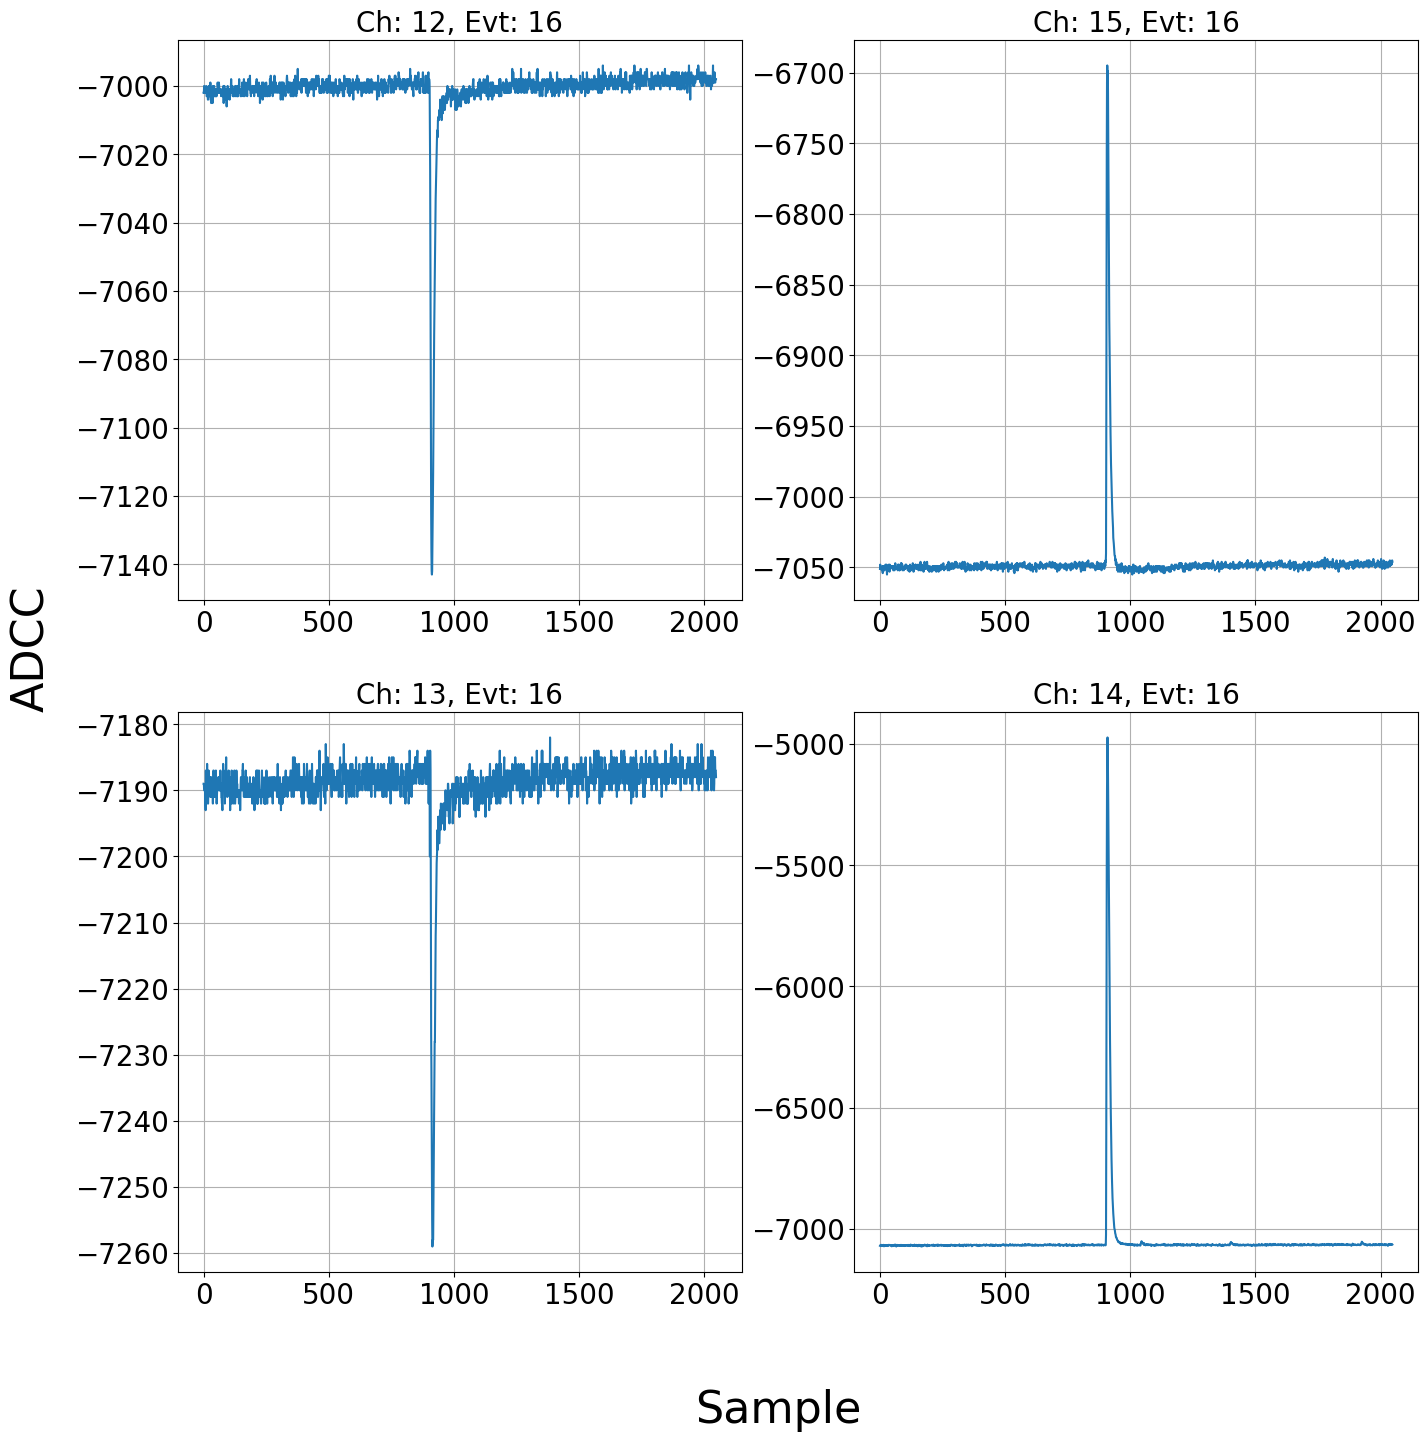

In [582]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
order = np.array([[0,0],[1,0],[1,1],[0,1]])
k = 0
for i,j in order:
    evt, ch = wf_ch_eventids[0]
    axs[i,j].plot(np.arange(0,2048,1), waveforms_co[evt][ch+k-(ch%4)],'-')
    #axs[i,j].set_ylim(-7050, -7020)
    axs[i,j].set_title(f'Ch: {ch+k-(ch%4)}, Evt: {evt}', fontsize=20)
    axs[i,j].grid()
    k += 1
fig.supxlabel('Sample', fontsize=32)
fig.supylabel('ADCC', fontsize=32)
plt.savefig('Ch1BigPulses.png')
plt.show()

In [249]:
print(d_co['p_bnds'][582])
print(cut_ch_pulseids[0])
print(cut_ch_eventids[0])

[[   1  136  240  322  419  493  592  891  973 1518 1998]
 [  48  172  278  384  454  570  628  972 1493 1827 2043]]
[1 8 6 7 5 6 4 3 6 2 5 4 4 7 5 4 6 4 5 3 1 6 4 5 7 7 5 6 6 6 6 7 4 4 5 5 8
 3 4 7 4]
[ 426  582  816  850 1149 1253 1354 1858 1970 3212 3429 3675 3688 4765
 5234 5424 5485 5496 5799 5844 6028 6073 6157 6200 6573 7144 7214 7270
 7395 7786 8228 8286 8508 8593 8630 9232 9744 9864 9890 9957 9962]


In [234]:
print(cut_ch_eventids)

[array([ 426,  582,  816,  850, 1149, 1253, 1354, 1858, 1970, 3212, 3429,
       3675, 3688, 4765, 5234, 5424, 5485, 5496, 5799, 5844, 6028, 6073,
       6157, 6200, 6573, 7144, 7214, 7270, 7395, 7786, 8228, 8286, 8508,
       8593, 8630, 9232, 9744, 9864, 9890, 9957, 9962], dtype=uint32), array([ 169, 1705, 1899, 2026, 2313, 2927, 3599, 4230, 4495, 4697, 4719,
       7127, 7319, 8648, 9337, 9393, 9835], dtype=uint32), array([  28,  277,  420,  642,  891, 1101, 1363, 2380, 2572, 2789, 4205,
       4833, 4839, 4961, 5052, 5321, 5598, 5814, 5821, 5906, 6408, 7200,
       7457, 8249, 8993, 9253], dtype=uint32), array([ 970, 1018, 1637, 1708, 2308, 2448, 2463, 2735, 3274, 3430, 3528,
       3606, 3761, 3804, 3817, 3874, 4123, 4183, 4392, 4723, 6117, 6479,
       7218, 7578, 7874, 7908, 8439, 8920, 8955, 9750], dtype=uint32), array([  73,  318,  781, 1077, 1735, 2543, 3949, 5100, 5370, 6232, 6290,
       6405, 6513, 7506, 8461, 8668, 9457, 9517], dtype=uint32), array([ 313,  587,  714,  745